# Tutorial: from an alignment to a SNP matrix

This hands-on tutorial walks through the full SNPick workflow on a tiny toy alignment: extracting variable sites, reading the reduced FASTA and VCF, using the ASC `fconst` counts, visualising the SNP matrix, and handling gaps.

It assumes `snpick` is on your `PATH` (e.g. `conda install -c bioconda snpick`). Every cell below is real, executed output.

In [1]:
!snpick --version

snpick 1.0.2


## 1. Build a small example alignment

We write six short sequences of equal length (an alignment is required). Most columns are constant; a handful carry SNPs, plus one ambiguous base (`N`).

In [2]:
seqs = {
    "ref":     "ACGTACGTACGTACGTACGTACGTACGTAC",
    "sample1": "ACGTTCGTACGCACGTACGTACGAACGTAC",
    "sample2": "ACGAACGTACGCACGTAGGTACGTACGTAC",
    "sample3": "ACGTTCGTACGTACGTACGTACGAACGTAC",
    "sample4": "ACGTACGTNCGCACGTAGGTACGTACGTAC",
    "sample5": "ACGAACGTACGCACGTACGTACGTACGTAC",
}
with open("example.fasta", "w") as fh:
    for name, seq in seqs.items():
        fh.write(f">{name}\n{seq}\n")

print(open("example.fasta").read())

>ref
ACGTACGTACGTACGTACGTACGTACGTAC
>sample1
ACGTTCGTACGCACGTACGTACGAACGTAC
>sample2
ACGAACGTACGCACGTAGGTACGTACGTAC
>sample3
ACGTTCGTACGTACGTACGTACGAACGTAC
>sample4
ACGTACGTNCGCACGTAGGTACGTACGTAC
>sample5
ACGAACGTACGCACGTACGTACGTACGTAC



## 2. Extract the variable sites

The reduced FASTA keeps only the columns that vary across samples — a much smaller, phylogenetics-ready alignment. Progress (including the ASC `fconst` counts) is printed to **stderr**.

In [3]:
!snpick -f example.fasta -o snps.fasta 2>&1

[snpick] Mapped 236 bytes. 6 sequences × 30 positions.
[snpick] 5 variable, 25 constant (A:7 C:7 G:7 T:4), 0 ambiguous-only, 30 total.
[snpick] ASC fconst: 7,7,7,4
[snpick] Pass 1 took 0.00s.
[snpick] Pass 2: Wrote 6 sequences to snps.fasta.
[snpick] Done in 0.00s. 5 vars from 6 seqs × 30 pos.


In [4]:
print(open("snps.fasta").read())

>ref
TATCT
>sample1
TTCCA
>sample2
AACGT
>sample3
TTTCA
>sample4
TACGT
>sample5
AACCT



The line `ASC fconst: A,C,G,T` reports how many constant sites of each base were dropped. Feed it straight to IQ-TREE so branch lengths stay unbiased:

```bash
iqtree2 -s snps.fasta -m GTR+ASC -fconst <A,C,G,T>
```

## 3. Generate a VCF

Add `--vcf` for a VCF v4.2 with per-sample genotypes. `--chrom` sets the contig name so it lines up with your reference.

In [5]:
!snpick -f example.fasta -o snps.fasta --vcf --chrom NC_000962.3 2>&1

[snpick] Mapped 236 bytes. 6 sequences × 30 positions.
[snpick] 5 variable, 25 constant (A:7 C:7 G:7 T:4), 0 ambiguous-only, 30 total.
[snpick] ASC fconst: 7,7,7,4
[snpick] Pass 1 took 0.00s.
[snpick] Pass 2: Wrote 6 sequences to snps.fasta.
[snpick] VCF written to snps.vcf.
[snpick] Done in 0.00s. 5 vars from 6 seqs × 30 pos.


In [6]:
vcf = open("snps.vcf").read()
# Show the column header and the data rows (skip the ## metadata lines)
for line in vcf.splitlines():
    if not line.startswith("##"):
        print(line)

#CHROM	POS	ID	REF	ALT	QUAL	FILTER	INFO	FORMAT	ref	sample1	sample2	sample3	sample4	sample5
NC_000962.3	4	.	T	A	.	PASS	NS=6	GT	0	0	1	0	0	1
NC_000962.3	5	.	A	T	.	PASS	NS=6	GT	0	1	0	1	0	0
NC_000962.3	12	.	T	C	.	PASS	NS=6	GT	0	1	1	0	1	1
NC_000962.3	18	.	C	G	.	PASS	NS=6	GT	0	0	1	0	1	0
NC_000962.3	24	.	T	A	.	PASS	NS=6	GT	0	1	0	1	0	0


Note how `sample4`'s `N` at a variable site becomes a missing genotype (`.`) and is excluded from `NS` (number of samples with data).

## 4. Visualise the SNP matrix

The reduced FASTA is small enough to plot directly: samples on the y-axis, variable positions on the x-axis, coloured by allele.

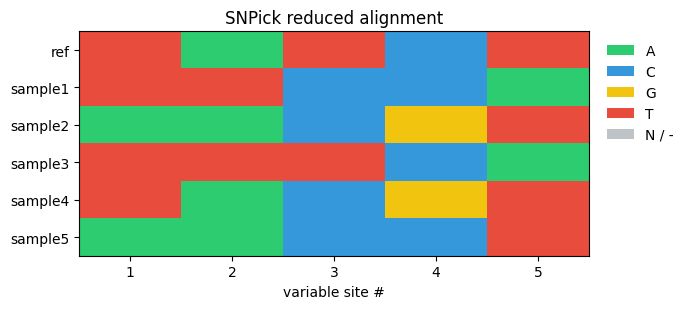

In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Read the reduced FASTA
names, rows = [], []
for block in open("snps.fasta").read().split(">")[1:]:
    head, seq = block.split(chr(10), 1)
    names.append(head.strip())
    rows.append(seq.replace(chr(10), "").strip())

code = {"A": 0, "C": 1, "G": 2, "T": 3, "N": 4, "-": 4}
mat = [[code.get(b, 4) for b in r] for r in rows]

colors = ["#2ecc71", "#3498db", "#f1c40f", "#e74c3c", "#bdc3c7"]
cmap = ListedColormap(colors)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.imshow(mat, cmap=cmap, vmin=0, vmax=4, aspect='auto')
ax.set_yticks(range(len(names)), names)
ax.set_xticks(range(len(rows[0])), range(1, len(rows[0]) + 1))
ax.set_xlabel("variable site #")
ax.set_title("SNPick reduced alignment")
legend = [Patch(facecolor=c, label=b) for b, c in zip("ACGT", colors)]
legend.append(Patch(facecolor=colors[4], label="N / -"))
ax.legend(handles=legend, bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

## 5. Include gaps

By default gaps (`-`) are ignored and never make a column variable. With `-g` a gap becomes a 5th allele — in the VCF an ALT gap is written `*`, while a gap in the reference is written `N` (`*` is not a legal REF allele).

In [8]:
gapped = {
    "ref":     "ACGTACGT",
    "sample1": "AC-TACGT",
    "sample2": "ACGTACGT",
}
with open("gaps.fasta", "w") as fh:
    for name, seq in gapped.items():
        fh.write(f">{name}\n{seq}\n")

print("Without -g:")
!snpick -f gaps.fasta -o nogap.fasta 2>&1 | grep variable
print(chr(10) + "With -g:")
!snpick -f gaps.fasta -o withgap.fasta -g 2>&1 | grep variable

Without -g:
[snpick] 0 variable, 8 constant (A:2 C:2 G:2 T:2), 0 ambiguous-only, 8 total.
[snpick] No variable positions — writing empty output.



With -g:
[snpick] 1 variable, 7 constant (A:2 C:2 G:1 T:2), 0 ambiguous-only, 8 total.


## Next steps

- [Usage reference](../../usage/) — every flag, with examples.
- [Output formats](../../output/) — the reduced FASTA, VCF v4.2 and `fconst` in detail.
- [Architecture](../../architecture/) — how the two-pass, memory-mapped scan works.
